This is to explore Long Short-Term Memory (LSTM) networks, a type of recurrent neural network (RNN), be use for stock price prediction

In [113]:
#
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

#import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error

import yfinance as yf

In [114]:
import warnings
warnings.filterwarnings("ignore")

In [115]:
# Data source from yfinance as below
#   tentatively retreive 3 years stock data

company = "0700.HK"
df_HKstock = yf.download(company, start="2024-01-01", end="2026-01-01",
                    auto_adjust=True ).droplevel('Ticker', axis=1)
df_HKstock

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,288.157806,296.318709,286.020414,291.461025,23354069
2024-01-03,292.043945,293.015482,284.077332,285.631797,20391718
2024-01-04,290.295166,295.735778,289.517948,295.735778,20217430
2024-01-05,283.883057,288.157813,281.357055,286.991957,23745017
2024-01-08,279.802582,286.214730,277.082291,286.020411,16718452
...,...,...,...,...,...
2025-12-23,595.066895,607.422935,594.572653,606.434451,15623392
2025-12-24,595.561157,595.561157,595.561157,595.561157,0
2025-12-29,589.630249,603.963256,589.136007,599.020840,18502650


In [116]:
# Save copy to CSV
df_HKstock.to_csv('0700.HK260101.csv')

In [117]:
#
df_source = pd.read_csv("0700.HK260101.csv")
df_source

,Date,Close,High,Low,Open,Volume
0,2024-01-02,288.157806,296.318709,286.020414,291.461025,23354069
1,2024-01-03,292.043945,293.015482,284.077332,285.631797,20391718
2,2024-01-04,290.295166,295.735778,289.517948,295.735778,20217430
3,2024-01-05,283.883057,288.157813,281.357055,286.991957,23745017
4,2024-01-08,279.802582,286.214730,277.082291,286.020411,16718452
...,...,...,...,...,...,...
487,2025-12-23,595.066895,607.422935,594.572653,606.434451,15623392
488,2025-12-24,595.561157,595.561157,595.561157,595.561157,0
489,2025-12-29,589.630249,603.963256,589.136007,599.020840,18502650
490,2025-12-30,593.089966,594.078449,587.159066,591.607241,13582535


In [118]:
# Set Date
df_source["Date"] = pd.to_datetime(df_source["Date"], format="%Y-%m-%d")
df_source

,Date,Close,High,Low,Open,Volume
0,2024-01-02,288.157806,296.318709,286.020414,291.461025,23354069
1,2024-01-03,292.043945,293.015482,284.077332,285.631797,20391718
2,2024-01-04,290.295166,295.735778,289.517948,295.735778,20217430
3,2024-01-05,283.883057,288.157813,281.357055,286.991957,23745017
4,2024-01-08,279.802582,286.214730,277.082291,286.020411,16718452
...,...,...,...,...,...,...
487,2025-12-23,595.066895,607.422935,594.572653,606.434451,15623392
488,2025-12-24,595.561157,595.561157,595.561157,595.561157,0
489,2025-12-29,589.630249,603.963256,589.136007,599.020840,18502650
490,2025-12-30,593.089966,594.078449,587.159066,591.607241,13582535


In [119]:
df_source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492 entries, 0 to 491
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    492 non-null    datetime64[ns]
 1   Close   492 non-null    float64       
 2   High    492 non-null    float64       
 3   Low     492 non-null    float64       
 4   Open    492 non-null    float64       
 5   Volume  492 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 23.2 KB


In [120]:
# Set Date as index - time series data
df_source = df_source.set_index('Date', ) 
df_source.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 492 entries, 2024-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   492 non-null    float64
 1   High    492 non-null    float64
 2   Low     492 non-null    float64
 3   Open    492 non-null    float64
 4   Volume  492 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.1 KB


In [121]:
df = df_source
df

,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,288.157806,296.318709,286.020414,291.461025,23354069
2024-01-03,292.043945,293.015482,284.077332,285.631797,20391718
2024-01-04,290.295166,295.735778,289.517948,295.735778,20217430
2024-01-05,283.883057,288.157813,281.357055,286.991957,23745017
2024-01-08,279.802582,286.214730,277.082291,286.020411,16718452
...,...,...,...,...,...
2025-12-23,595.066895,607.422935,594.572653,606.434451,15623392
2025-12-24,595.561157,595.561157,595.561157,595.561157,0
2025-12-29,589.630249,603.963256,589.136007,599.020840,18502650


In [122]:
# Data pre-processing
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [123]:
# This is preserve as for handling missing values, if applicable
df.bfill()

,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,288.157806,296.318709,286.020414,291.461025,23354069
2024-01-03,292.043945,293.015482,284.077332,285.631797,20391718
2024-01-04,290.295166,295.735778,289.517948,295.735778,20217430
2024-01-05,283.883057,288.157813,281.357055,286.991957,23745017
2024-01-08,279.802582,286.214730,277.082291,286.020411,16718452
...,...,...,...,...,...
2025-12-23,595.066895,607.422935,594.572653,606.434451,15623392
2025-12-24,595.561157,595.561157,595.561157,595.561157,0
2025-12-29,589.630249,603.963256,589.136007,599.020840,18502650


In [124]:
# Calculate moving averages and daily returns

df['20-day MA'] = df['Close'].rolling(window=20).mean()
df['50-day MA'] = df['Close'].rolling(window=50).mean()
df['Daily Return'] = df['Close'].pct_change()

In [125]:
# To check NaN
df[df.isna().values==True].drop_duplicates()

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2024-01-02,288.157806,296.318709,286.020414,291.461025,23354069,NaN,NaN,NaN
2024-01-03,292.043945,293.015482,284.077332,285.631797,20391718,NaN,NaN,0.013486
2024-01-04,290.295166,295.735778,289.517948,295.735778,20217430,NaN,NaN,-0.005988
2024-01-05,283.883057,288.157813,281.357055,286.991957,23745017,NaN,NaN,-0.022088
2024-01-08,279.802582,286.214730,277.082291,286.020411,16718452,NaN,NaN,-0.014374
2024-01-09,275.527832,280.968444,275.333513,277.859514,16927478,NaN,NaN,-0.015278
2024-01-10,272.224609,277.082293,268.921361,273.973364,19146068,NaN,NaN,-0.011989
2024-01-11,279.219635,284.077318,272.030270,272.613197,20604580,NaN,NaN,0.025696
2024-01-12,280.191193,284.660268,276.693654,277.470902,15770055,NaN,NaN,0.003480


In [126]:
df = df.dropna()   # Drop all NaN
df

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2024-03-13,282.328583,285.631802,280.385509,283.105800,20074418,274.002510,274.859403,-0.000688
2024-03-14,280.968445,285.631809,278.636733,281.162734,14227432,274.187102,274.715616,-0.004818
2024-03-15,275.722107,278.053819,271.641671,274.944889,29183023,273.798486,274.389179,-0.018672
2024-03-18,281.551331,283.105795,274.167675,274.167675,19633305,274.041370,274.214302,0.021142
2024-03-19,276.887970,282.911510,276.887970,280.774117,15635351,274.080231,274.074401,-0.016563
...,...,...,...,...,...,...,...,...
2025-12-23,595.066895,607.422935,594.572653,606.434451,15623392,601.986298,616.210574,-0.020342
2025-12-24,595.561157,595.561157,595.561157,595.561157,0,601.146088,615.844835,0.000831
2025-12-29,589.630249,603.963256,589.136007,599.020840,18502650,600.404724,615.241860,-0.009959


In [127]:
# Configuration

# For ~ 80:20 Split
test_days = 90

# choose the number of days on which to base our predictions 
nb_days = 60

# Number of days into the future we want to predict
n_steps_out = 30

#
epochsMS=15 
batch_sizeMS = 32
epochs2=30 
batch_size2 = 32

In [128]:
# For normailized Data

# from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))  
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [129]:
# ADF Test : p-value < 0.05 for stationary data

#from statsmodels.tsa.stattools import adfuller

close_series = df['Close']
def check_stationarity(series):
    result = adfuller(series.dropna())  # Drop NaN values if any
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

check_stationarity(close_series)

ADF Statistic: -1.2877625878122436
p-value: 0.6347521826904193
The series is not stationary.


# To transform time series stationary...
There are three major time series patterns: trend, seasonality, and cycles. Trend and cycles are usually combined into a single component, with a trend-cycle component, a seasonal component, and a remainder component (containing the rest of the time series).

To make time series stationary, the principle is to estimate trend and seasonality, and to remove those from the time series. Then to apply the forecasting technique (i.e here LSTM), the final step being to convert the forcasted values into the original scale by adding the estimated trend and seasonality.

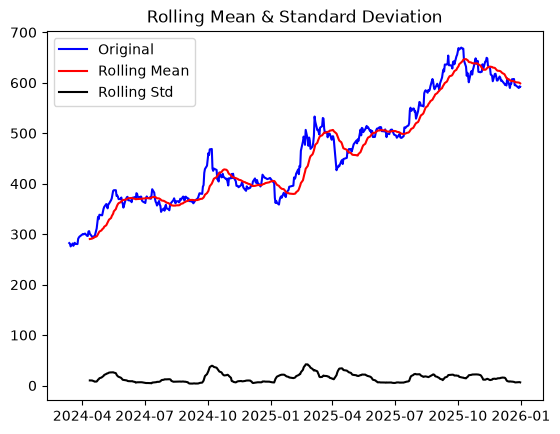

Results of Dickey-Fuller Test:
Test Statistic                  -1.287763
p-value                          0.634752
#Lags Used                       0.000000
Number of Observations Used    442.000000
Critical Value (1%)             -3.445232
Critical Value (5%)             -2.868101
Critical Value (10%)            -2.570265
dtype: float64


In [130]:
#... The following cells are use for model(s), such as LSTM in transformation
#... test stationarity with DFT

close_series = df['Close']
def test_stationarity(timeseries):
    '''
    Input: timeseries (dataframe): timeseries for which we want to study the stationarity
    '''
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(20).mean()
    rolstd = timeseries.rolling(20).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value',\
                                             '#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

test_stationarity(close_series)

<Figure size 640x480 with 0 Axes>

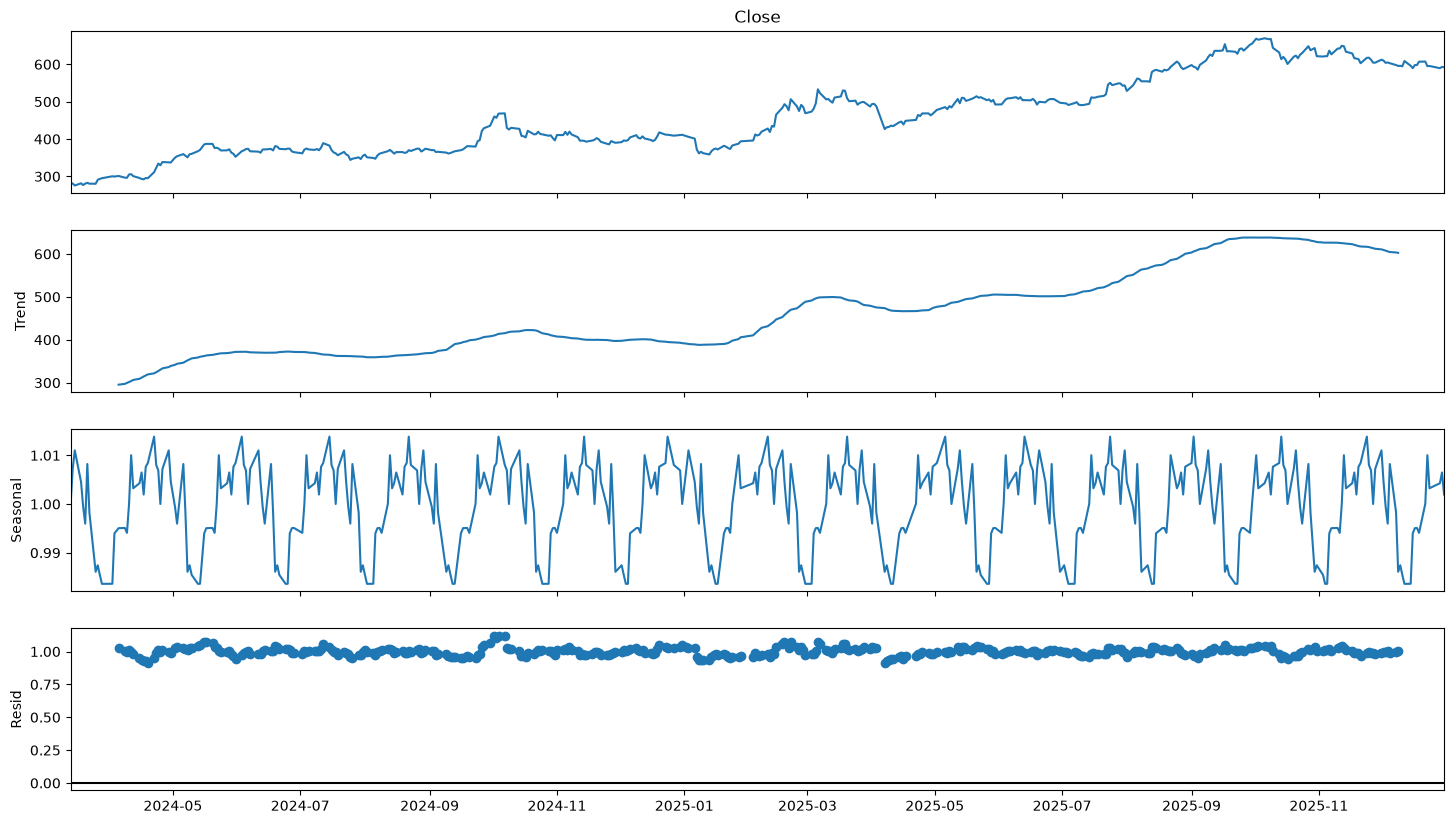

In [131]:
#from statsmodels.tsa.seasonal import seasonal_decompose

#To plot & view the trend and the seasonality
# here set the period to 28 as monthly average 

df_close = df['Close']
result = seasonal_decompose(df_close, model='multiplicative',period=28)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(16, 9)

Text(0.5, 1.0, 'Transformed data')

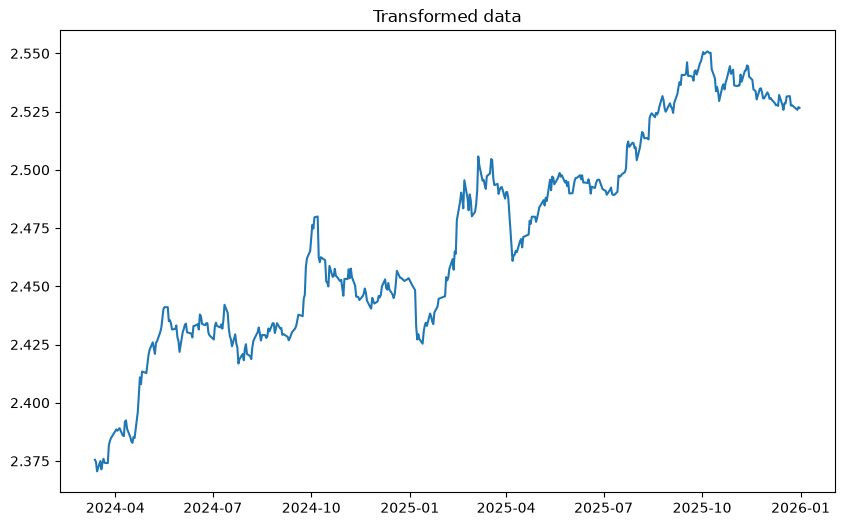

In [132]:
#... To apply log transform to reduce the trends effect while square root transform to flatten 

df_close_log = df_close.apply(np.log)
df_close_tf = df_close_log.apply(np.sqrt)

plt.figure(figsize = (10,6))
plt.plot(df_close_tf)
plt.title('Transformed data')

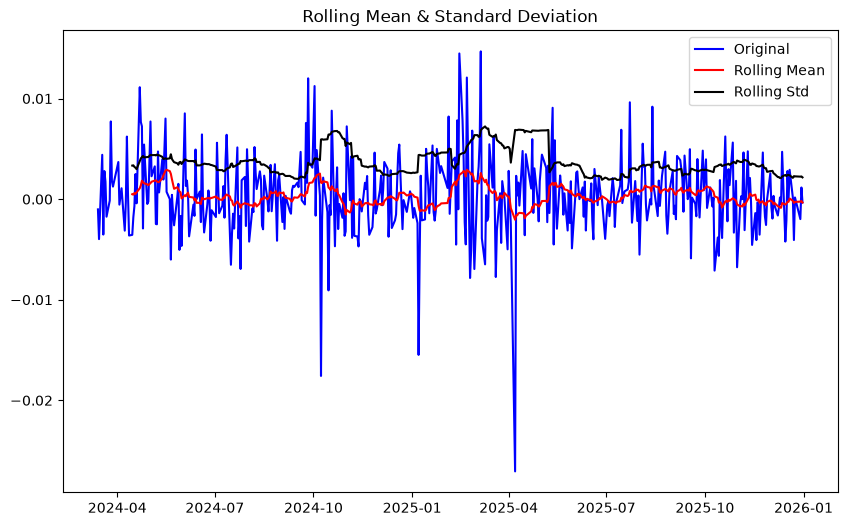

Results of Dickey-Fuller Test:
Test Statistic                 -20.610496
p-value                          0.000000
#Lags Used                       0.000000
Number of Observations Used    441.000000
Critical Value (1%)             -3.445266
Critical Value (5%)             -2.868116
Critical Value (10%)            -2.570273
dtype: float64


In [133]:
#... classical methold differenciating to handel with trand and seasonality
df_close_shift = df_close_tf - df_close_tf.shift()

df_close_shift.dropna(inplace=True)
plt.figure(figsize = (10,6))
test_stationarity(df_close_shift)

check p-value

In [134]:
#...MS LSTM
def preprocess_lstm(sequence, n_steps,n_features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the sequence
        if end_ix >= len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, y

# choose the number of days on which to base our predictions 
#nb_days = 60
n_features = 1

X, y = preprocess_lstm(df_close_shift.to_numpy(), nb_days, n_features)

#Split the data set between the training set and the test set (20%)
#test_days = 135 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

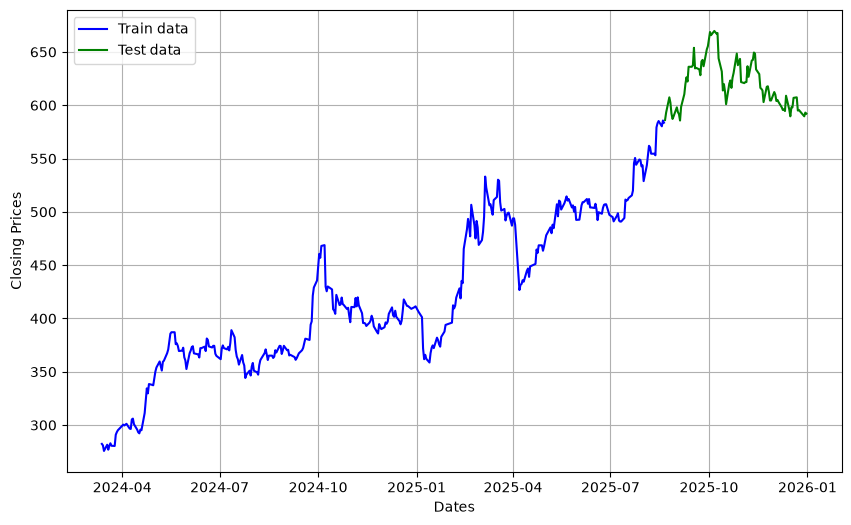

In [135]:
#... Split Data
train_original = df_close.iloc[:-test_days]
test_original = df_close.iloc[-test_days:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.legend()

In [136]:
#... LSTM Vanilla LSTM
def vanilla_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(1))
    return model

#
model = vanilla_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])    

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [137]:
#...Train and evaluate model
model.fit(X_train, 
          y_train, 
          epochs=epochsMS, 
          batch_size = batch_sizeMS)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 4.8229e-05 - mean_absolute_error: 0.0055
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2.6083e-05 - mean_absolute_error: 0.0040
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 2.0683e-05 - mean_absolute_error: 0.0032
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1.9058e-05 - mean_absolute_error: 0.0031
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 1.9347e-05 - mean_absolute_error: 0.0031
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 1.8173e-05 - mean_absolute_error: 0.0030
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1.8169e-05 - mean_absolute_error: 0.0030
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 1.7832e-05 - mean_absolute_error: 0.0030
Epoch 9/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 1.7724e-05 - mean_absolute_error: 0.0029
Epoch 10/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 1.8449e-05 - mean_absolute_error: 0.0030

In [138]:
#...
# Evaluate the model on the test data using
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)
print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 8.4785e-06 - mean_absolute_error: 0.0023 
Test MSE: 8.478537893097382e-06
Test MAE: 0.00225941208191216


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step


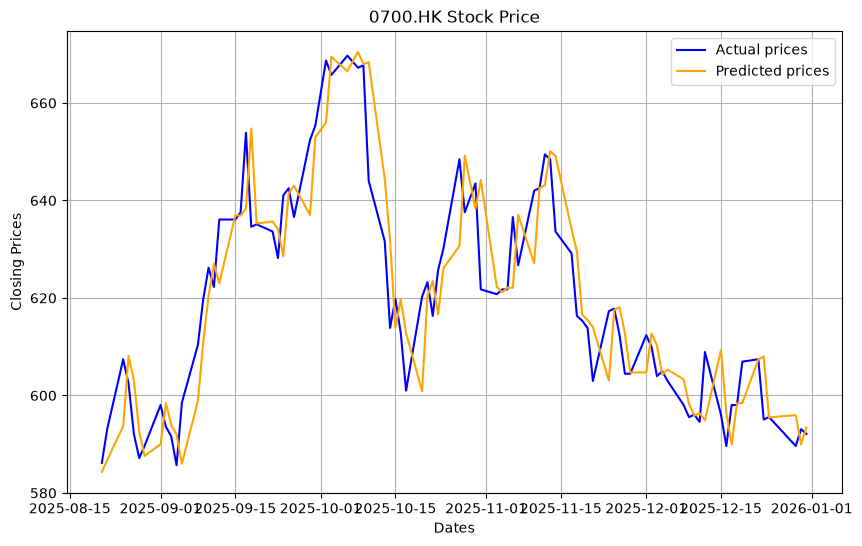

In [139]:
#...
# Prediction
y_pred = model.predict(X_test)

# We create a dataframe from y_pred to have date-time indexes.
pred_data = pd.DataFrame(y_pred[:,0], test_original.index,columns=['Close'])

# Apply inverse transformation from 1.d

# Add the differenciation term
pred_data['Close'] = pred_data['Close'] + df_close_tf.shift().values[-test_days:] 

# Take the square, and the exponent
pred_data = pred_data.apply(np.square)
pred_data = pred_data.apply(np.exp)

# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original,'b',label='Actual prices')
plt.plot(pred_data, 'orange',label='Predicted prices')
#plt.title(' Stock Price')
plt.title(company + ' Stock Price')

plt.legend()

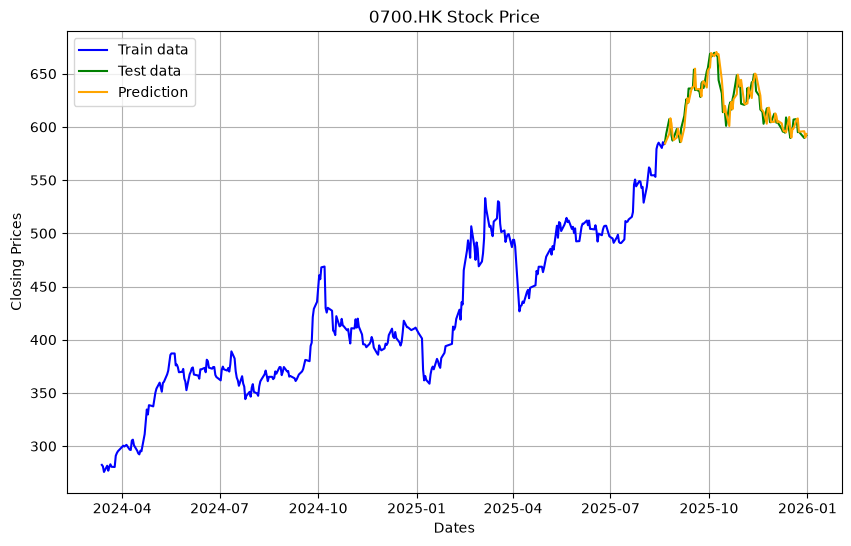

In [140]:
#...
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.plot(pred_data, 'orange', label='Prediction')
plt.title(company + ' Stock Price')
plt.legend()

In [141]:
#...Multiple-Step LSTM
def preprocess_multistep_lstm(sequence, n_steps_in, n_steps_out, features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the sequence
        if out_end_ix > len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)

    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    
    return X, y

# Number of days into the future we want to predict
#n_steps_out = 30

# choose the number of days on which to base our predictions 
#nb_days = 60

n_features = 1

X, y = preprocess_multistep_lstm(df_close_shift.to_numpy(), nb_days, n_steps_out, n_features)

#
#Split the data set between the training set and the test set (20%)
#test_days = 135 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

In [142]:
#...
def vanilla_multistep_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(n_steps_out))
    return model

#
model = vanilla_multistep_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 30)                  │           1,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,930 (46.60 KB)

 Trainable params: 11,930 (46.60 KB)

 Non-trainable params: 0 (0.00 B)

In [143]:
#...
model.fit(X_train, 
          y_train, 
          epochs=epochsMS, 
          batch_size = batch_sizeMS)

Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 2.0255e-05 - mean_absolute_error: 0.0032
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 1.9903e-05 - mean_absolute_error: 0.0031
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 1.9397e-05 - mean_absolute_error: 0.0031
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 1.9428e-05 - mean_absolute_error: 0.0031
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 1.9525e-05 - mean_absolute_error: 0.0031
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 1.9408e-05 - mean_absolute_error: 0.0031
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 1.9061e-05 - mean_absolute_error: 0.0030
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 1.9352e-05 - mean_absolute_error: 0.0031
Epoch 9/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 1.9207e-05 - mean_absolute_error: 0.0031
Epoch 10/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 1.9368e-05 - mean_absolute_error: 0.0031
Epoch 11/15
9/9 ━━━

In [144]:
#...
# Evaluate the model on the test set
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)

print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.0150e-05 - mean_absolute_error: 0.0025 
Test MSE: 1.0150235539185815e-05
Test MAE: 0.0024986928328871727


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step


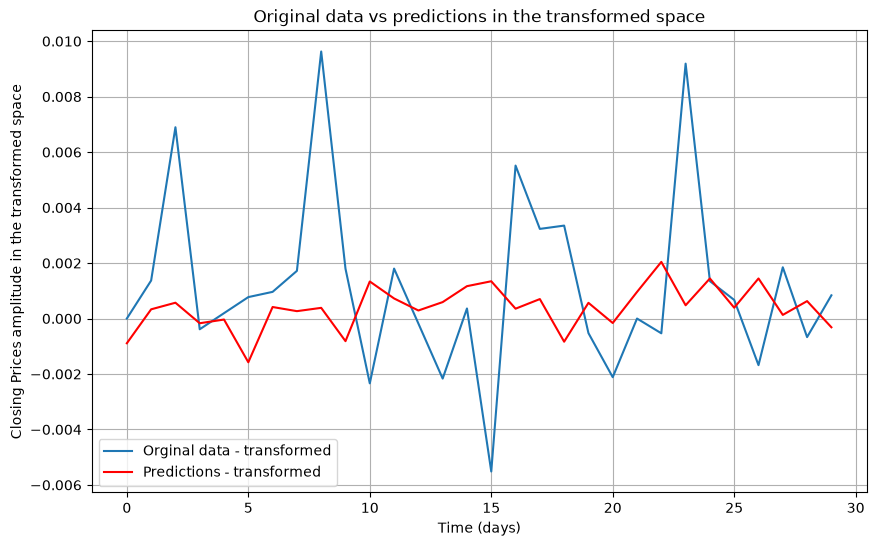

In [145]:
#...
# Prediction
y_pred = model.predict(X_test)

# the_day is the day from which we will study the n_steps_out-th dayS of prediction into 
# the future. Note: The first day start at index 0
the_day = 0
y_pred_days = y_pred[the_day,:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.plot(y_test[the_day,:],label='Orginal data - transformed')
plt.plot(y_pred_days, color='red',label='Predictions - transformed')
plt.xlabel('Time (days)')
plt.ylabel('Closing Prices amplitude in the transformed space')
plt.title('Original data vs predictions in the transformed space')
plt.legend()

In [146]:
#...
# Apply inverse transformations from 3.a

# Add the differenciation term
pred_diff_cumsum = y_pred_days.cumsum()

base_number = df_close_tf.values[-test_days+the_day+nb_days-1]
idx = test_original.iloc[the_day:the_day+n_steps_out].index

pred_tf = pd.Series(base_number, index=idx)
pred_tf = pred_tf.add(pred_diff_cumsum,fill_value=0)

print(pred_tf)

Date
2025-08-21    2.537691
2025-08-22    2.538023
2025-08-25    2.538593
2025-08-26    2.538424
2025-08-27    2.538387
2025-08-28    2.536810
2025-08-29    2.537226
2025-09-01    2.537492
2025-09-02    2.537877
2025-09-03    2.537061
2025-09-04    2.538397
2025-09-05    2.539121
2025-09-08    2.539411
2025-09-09    2.540003
2025-09-10    2.541170
2025-09-11    2.542514
2025-09-12    2.542869
2025-09-15    2.543571
2025-09-16    2.542736
2025-09-17    2.543302
2025-09-18    2.543141
2025-09-19    2.544100
2025-09-22    2.546142
2025-09-23    2.546620
2025-09-24    2.548064
2025-09-25    2.548454
2025-09-26    2.549899
2025-09-29    2.550030
2025-09-30    2.550658
2025-10-02    2.550343
dtype: float64


In [147]:
#...
# Take the square, and the exponent
pred_log = pred_tf.apply(np.square)
pred = pred_log.apply(np.exp)
print(pred)

Date
2025-08-21    626.329486
2025-08-22    627.386027
2025-08-25    629.204454
2025-08-26    628.662657
2025-08-27    628.546470
2025-08-28    623.535535
2025-08-29    624.851226
2025-09-01    625.695372
2025-09-02    626.920358
2025-09-03    624.330025
2025-09-04    628.577237
2025-09-05    630.891366
2025-09-08    631.821609
2025-09-09    633.725567
2025-09-10    637.494855
2025-09-11    641.865278
2025-09-12    643.025024
2025-09-15    645.324251
2025-09-16    642.588516
2025-09-17    644.442705
2025-09-18    643.914187
2025-09-19    647.065044
2025-09-22    653.824493
2025-09-23    655.419393
2025-09-24    660.258565
2025-09-25    661.571162
2025-09-26    666.462207
2025-09-29    666.907318
2025-09-30    669.048487
2025-10-02    667.973363
dtype: float64


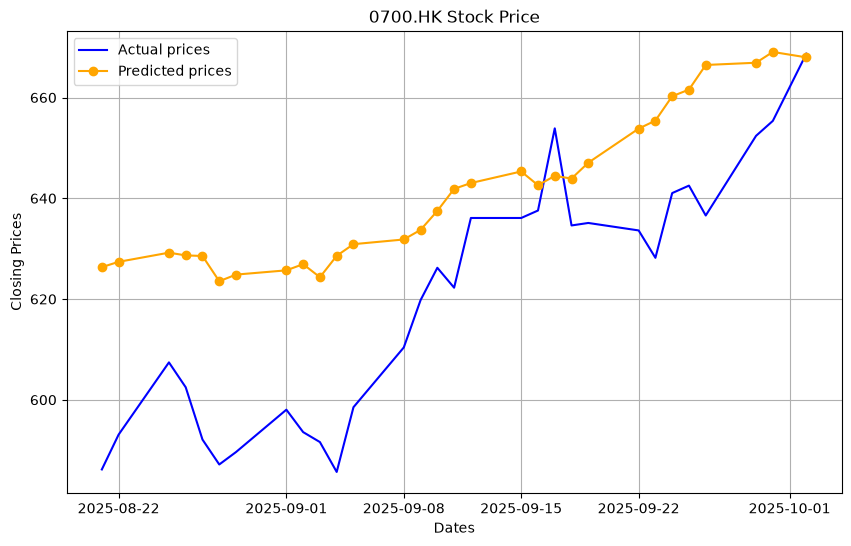

In [148]:
#...
# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original.iloc[max(0,the_day-30):the_day+n_steps_out],'b',label='Actual prices')
plt.plot(pred, '-o',color='orange',label='Predicted prices')
plt.title(company + ' Stock Price')

plt.legend()

In [149]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns
from sklearn.metrics import r2_score
import statsmodels.api as sm

# 1. Extract the exact actual prices that align with the prediction period
# Based on your plot, 'pred' starts at 'the_day' and goes forward for 'n_steps_out' steps.
actual_for_pred_period = test_original.iloc[the_day : the_day + n_steps_out]

# 2. Ensure both are flattened 1D arrays/Series with no missing values
y_true = actual_for_pred_period.values.flatten()
y_pred = pred.flatten() if hasattr(pred, 'flatten') else pred

X = sm.add_constant(y_true)

#fit linear regression model
model = sm.OLS(y_pred, X).fit()

#view model summary
summary = model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.800
Method:                 Least Squares   F-statistic:                     116.8
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           1.68e-11
Time:                        21:02:03   Log-Likelihood:                -98.845
No. Observations:                  30   AIC:                             201.7
Df Residuals:                      28   BIC:                             204.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        298.4850     31.734      9.406      0.0

In [150]:
#import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Replace these arrays with your actual test data and model predictions
# Example: y_true (actual market prices), y_pred (your LSTM or ARIMA predictions)
#y_true = np.array([100.0, 102.5, 101.2, 105.0, 107.8])
#y_pred = np.array([101.2, 101.0, 102.0, 104.5, 109.1])

# 2. Calculate Standard Regression Metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)  # Alternative: mean_squared_error(y_true, y_pred, squared=False)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# 3. Calculate Directional Accuracy (Crucial for price trends)
# Compares if the predicted direction (up/down) matches the actual direction
actual_direction = np.diff(y_true) > 0
predicted_direction = np.diff(y_pred) > 0
directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

# 4. Print Evaluation Results
print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Pct Error (MAPE): {mape:.2f}%")
print(f"R² Score (Goodness of Fit):     {r2:.4f}")
print(f"Directional Accuracy (DA):      {directional_accuracy:.2f}%")


--- Model Evaluation Metrics ---
Mean Absolute Error (MAE):      22.0723
Mean Squared Error (MSE):       616.4633
Root Mean Squared Error (RMSE): 24.8287
Mean Absolute Pct Error (MAPE): 3.63%
R² Score (Goodness of Fit):     -0.0605
Directional Accuracy (DA):      68.97%


In [158]:
# Follow from ADF Test if series is stationary
scaler = MinMaxScaler()
df['Close'] = scaler.fit_transform(df[['Close']])

In [159]:
# Train and Verify Split (80:20 Ratio)
#from sklearn.model_selection import train_test_split

def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back)])
        dataY.append(dataset[i + look_back])
    return np.array(dataX), np.array(dataY)

close_values = df['Close'].values 

X, Y = create_dataset(close_values, look_back=30)

trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, shuffle=False)


In [160]:
# Data for LSTM 
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

In [154]:
#1 LSTM ***SKIP
model = Sequential()
model.add(LSTM(units=50, input_shape=(30, 1)))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()
model.fit(trainX, trainY, epochs=epochs2, batch_size=bach_size2)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1439
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0168
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0071
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0063
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0048
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0039
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0034
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0031
Epoch 9/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0028
Epoch 10/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0027
Epoch 11/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026
Epoch 12/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026
Epoch 13/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0025
Epoch 14/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0024
Epoch 15/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0024
Epoc

#
LSTM(50 units) → Captures long-term dependencies

Dropout(0.2) → Prevents overfitting

Dense Layers → Produces final prediction

In [161]:
#2 LSTM
#from tensorflow.keras.models import Sequential  
#from tensorflow.keras.layers import LSTM, Dense, Dropout  

model = Sequential([  
    LSTM(units=50, return_sequences=True, input_shape=(trainX.shape[1], 1)),  
    Dropout(0.2),  
    LSTM(units=50, return_sequences=False),  
    Dropout(0.2),  
    Dense(units=25),  
    Dense(units=1)  
])  

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(trainX, trainY, epochs=epochs2, batch_size=batch_size2)

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0732
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0126
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0075
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0064
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0063
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0048
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0041
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0038
Epoch 9/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0043
Epoch 10/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0038
Epoch 11/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0034
Epoch 12/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0037
Epoch 13/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0041
Epoch 14/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0037
Epoch 15/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0038
Epoc

In [162]:
# Prediction & Result
testPredict = model.predict(testX)
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform(testY.reshape(-1, 1))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step


In [163]:
#from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(testY, testPredict))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 0.05770409473601676


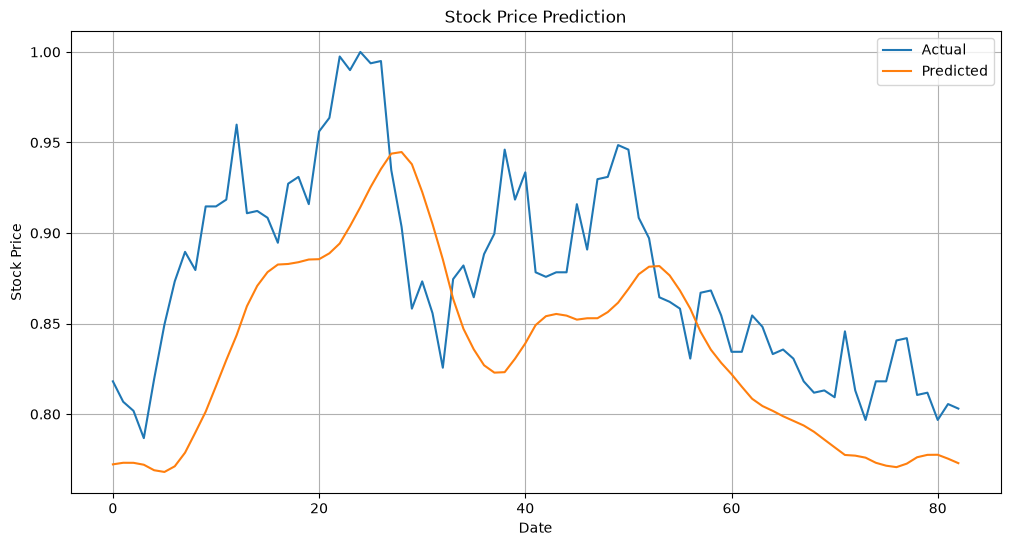

In [164]:
#2
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Price Prediction")
plt.plot(testY, label='Actual')
plt.plot(testPredict, label='Predicted')
plt.grid(True)
plt.legend()
plt.show()

For this study, we will focus on the closing price, as it represents the final market sentiment for each trading day.